# Lab Instructions

Find a dataset that interests you. I'd recommend starting on [Kaggle](https://www.kaggle.com/). Read through all of the material about the dataset and download a .CSV file.

1. Write a short summary of the data.  Where did it come from?  How was it collected?  What are the features in the data?  Why is this dataset interesting to you?  

2. Identify 5 interesting questions about your data that you can answer using Pandas methods.  

3. Answer those questions!  You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers.  LLMs will not always write code in this way without specific instruction.  

4. Write the answer to your question in a text box underneath the code you used to calculate the answer.



# Summery of data
I selected the Google Play Store Apps dataset from Kaggle. This dataset contains information about thousands of applications available on the Google Play Store, including app ratings, review counts, install counts, pricing information, content ratings, categories, and Android version requirements. The data was collected by scraping publicly available information from the Google Play Store and compiling it into a structured dataset for analysis.

Some of the features included in the dataset are the application name, category, user rating, number of reviews, application size, number of installs, whether the application is free or paid, price, content rating, genre, last updated date, current version, and required Android version. These features provide insight into both the popularity and characteristics of mobile applications.

I found this dataset particularly interesting because I am currently studying Mobile Application Development and developing several productivity-focused applications of my own. Analyzing real-world app data allows me to explore what characteristics successful applications share, such as high ratings, large install counts, and pricing strategies. This dataset provides an opportunity to better understand the mobile application marketplace while practicing data analysis techniques.

# 5 Questions
How many installs do the 10 most installed productivity apps have?
Do free or paid productivity apps have higher average ratings?
What are the highest-rated productivity apps with at least 10,000 reviews?
What Andriod version is supporeted by the largest number of productivty apps?
What is the average price of paid productivity applications?

In [22]:
import pandas as pd

df = pd.read_csv('googleplaystore.csv')

How many installs do the 10 most installed productivity apps have?

In [12]:
productivity_df = df[df['Category'] == 'PRODUCTIVITY'].copy()

productivity_df.head()

productivity_df['Installs_Clean'] = (
    productivity_df['Installs']
    .str.replace(',', '')
    .str.replace('+', '', regex=False)
    .astype(int)
)

productivity_df.drop_duplicates(
    subset='App'
).sort_values(
    by='Installs_Clean',
    ascending=False
)[['App', 'Installs']].head(10)

,App,Installs
3454,Google Drive,"1,000,000,000+"
3450,Microsoft Word,"500,000,000+"
3473,Dropbox,"500,000,000+"
3574,Cloud Print,"500,000,000+"
3476,Google Calendar,"500,000,000+"
7808,CamScanner - Phone PDF Creator,"100,000,000+"
3467,Google Keep,"100,000,000+"
3535,ColorNote Notepad Notes,"100,000,000+"
3482,"Evernote – Organizer, Planner for Notes & Memos","100,000,000+"
3531,"WPS Office - Word, Docs, PDF, Note, Slide & Sheet","100,000,000+"


The top ten most installed Productivity apps are all over 100,000,000 installs.  There seems to be a high number of large tech companies like Google, Microsoft, and Dropbox that are integrated with everything.

Do free or paid productivity apps have higher average ratings?

In [13]:
productivity_df.groupby('Type')['Rating'].mean()

Type
Free    4.211712
Paid    4.205556
Name: Rating, dtype: float64

It seems as if there is no difference in the rating between of the free versus paid applications.  Paid is not always better in the eyes of the consumer.

What are the highest-rated productivity apps with at least 10,000 reviews?

In [14]:
productivity_df['Reviews'] = pd.to_numeric(
    productivity_df['Reviews'],
    errors='coerce'
)

high_rated = (
    productivity_df[productivity_df['Reviews'] >= 10000]
    .sort_values(by='Rating', ascending=False)
)

high_rated[['App', 'Rating', 'Reviews']].head(10)

,App,Rating,Reviews
3464,Calculator - unit converter,4.7,287250
3498,Loop - Habit Tracker,4.7,17955
3481,Content Transfer,4.7,19302
4968,Best Applock - Locker & No Ads,4.7,10672
8633,To Do List,4.7,253155
4079,Mobile Security & Antivirus,4.7,564759
3451,"All-In-One Toolbox: Cleaner, Booster, App Manager",4.7,536926
6213,ALL-IN-ONE PACKAGE TRACKING,4.7,167406
8922,Clean My Android,4.7,101163
9785,ES File Explorer/Manager PRO,4.7,81614


This list shows that there is no certian productivty type that is rated the highest.  Everything from a calculator to Decluttering apps have found their way to the top of the list with ratings.

What Andriod version is supporeted by the largest number of productivty apps?

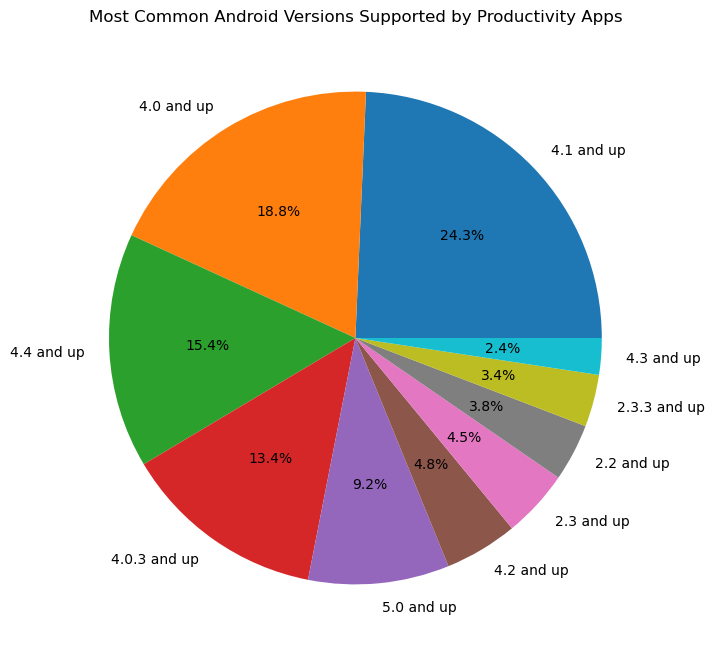

In [27]:
top_android_by_count = (
    productivity_df[
        productivity_df['Android Ver'] != 'Varies with device'
    ]['Android Ver']
    .value_counts()
    .head(10)
)

top_android_by_count.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8, 8),
    ylabel=''
)

plt.title('Most Common Android Versions Supported by Productivity Apps')
plt.show()

This graphs shows that a vase majority of the Andriod versions supported is 4.0 and up at the time the data was collected with a small portion being in the 2.2 and up.

What are the price statistics of paid productivity applications? Highest, lowest, average, and most common price?

In [28]:
paid_apps = productivity_df[productivity_df['Type'] == 'Paid'].copy()

paid_apps['Price_Clean'] = (
    paid_apps['Price']
    .str.replace('$', '', regex=False)
    .astype(float)
)

highest_price = paid_apps['Price_Clean'].max()
lowest_price = paid_apps['Price_Clean'].min()
average_price = paid_apps['Price_Clean'].mean()
most_common_price = paid_apps['Price_Clean'].mode()[0]

print(f"Highest Price: ${highest_price:.2f}")
print(f"Lowest Price: ${lowest_price:.2f}")
print(f"Average Price: ${average_price:.2f}")
print(f"Most Common Price: ${most_common_price:.2f}")

Highest Price: $154.99
Lowest Price: $0.99
Average Price: $8.96
Most Common Price: $2.99


The price statistics show a massive difference between the highest paid app and the most common paid app.  This shows that most developers price their applications lower to allow more individuals to be able to purchase them.